In [6]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df=pd.read_csv('covid_toy.csv')

In [4]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

<Axes: xlabel='fever', ylabel='count'>

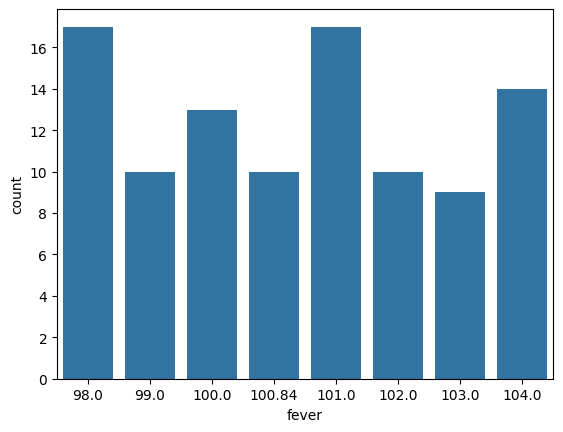

In [8]:
# filling the missing values of fever column with mean

df['fever']=df['fever'].fillna(df['fever'].mean()).round(2)
sns.countplot(x=df['fever'])

In [9]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [10]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


In [26]:
X=df[['age','gender','fever','cough','city']]
y=df['has_covid']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train['cough'].value_counts()
# X_test.shape

cough
Mild      48
Strong    32
Name: count, dtype: int64

In [33]:
#Ordinal Encoding in cough
oe=OrdinalEncoder(categories=[['Mild','Strong']])
X_train_cough=oe.fit_transform(X_train[['cough']])
X_test_cough=oe.transform(X_test[['cough']])

In [38]:
# One hot Encoding in gender and city
ohe=OneHotEncoder(drop='first',sparse_output=False)
X_train_gender_city=ohe.fit_transform(X_train[['gender','city']])
X_test_gender_city=ohe.transform(X_test[['gender','city']])

In [40]:
X_train_age_fever=X_train[['age','fever']]
X_test_age_fever=X_test[['age','fever']]


In [41]:
X_train_transformed=np.concatenate((X_train_age_fever,X_train_gender_city,X_train_cough),axis=1)
X_test_transformed=np.concatenate((X_test_age_fever,X_test_gender_city,X_test_cough),axis=1)
X_train_transformed

array([[ 81.  , 101.  ,   0.  ,   0.  ,   0.  ,   1.  ,   0.  ],
       [  5.  , 100.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ],
       [ 19.  , 100.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ],
       [ 27.  , 100.  ,   1.  ,   1.  ,   0.  ,   0.  ,   0.  ],
       [ 73.  , 103.  ,   0.  ,   1.  ,   0.  ,   0.  ,   0.  ],
       [ 70.  , 103.  ,   1.  ,   0.  ,   1.  ,   0.  ,   1.  ],
       [ 49.  , 102.  ,   0.  ,   1.  ,   0.  ,   0.  ,   0.  ],
       [ 51.  , 101.  ,   0.  ,   0.  ,   1.  ,   0.  ,   1.  ],
       [ 64.  , 101.  ,   0.  ,   1.  ,   0.  ,   0.  ,   0.  ],
       [ 83.  , 101.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ],
       [ 65.  ,  98.  ,   0.  ,   0.  ,   0.  ,   1.  ,   0.  ],
       [ 18.  , 104.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ],
       [ 16.  , 103.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ],
       [ 16.  , 104.  ,   1.  ,   0.  ,   1.  ,   0.  ,   0.  ],
       [ 27.  , 100.  ,   1.  ,   0.  ,   1.  ,   0.  ,   0.  ],
       [ 84.  , 100.84,  